# Выбор порогового коэффициента корреляции

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
import yfinance as yf
from scipy import stats

In [ ]:
plt.style.use('ggplot')

Рынок Германии, 10 низкокоррелированных акций:

In [ ]:
de_tickers = ['FRE.DE', 'BEI.DE', 'MRK.DE', 'FME.DE', 'ADS.DE', 'HEN3.DE', 'DHL.DE', 'CON.DE', 'TKA.DE', 'BMW.DE']

initial_df = yf.download(de_tickers, start='2005-01-01', end='2013-01-01', auto_adjust=True)['Close']
initial_df.head(5)

[*********************100%***********************]  10 of 10 completed


Ticker,ADS.DE,BEI.DE,BMW.DE,CON.DE,DHL.DE,FME.DE,FRE.DE,HEN3.DE,MRK.DE,TKA.DE
Date,,,,,,,,,,
2005-01-03,23.480194,21.549088,15.662539,26.694902,15.669333,13.965590,5.884089,14.458951,18.830330,10.954882
2005-01-04,23.359800,21.930489,15.973469,27.086647,15.478797,13.820820,5.942479,14.526330,18.531612,11.035531
2005-01-05,23.068533,21.927982,16.029158,26.778847,15.424357,13.706413,6.095849,14.533068,18.114880,10.867512
2005-01-06,23.175331,21.887836,16.108047,27.058666,15.469722,13.566311,6.150345,14.829525,18.162821,10.961605
2005-01-07,23.039404,21.882814,16.057003,27.002705,15.560454,13.566311,6.126989,15.045128,18.074314,10.995208


In [ ]:
df = pd.DataFrame([initial_df.iloc[row] / initial_df.iloc[row-1] for row in range(1, initial_df.shape[0])], index=initial_df.index[1:]) # расчет доходностей
df = np.log(df) # логарифмические доходности
df.dropna(inplace=True, axis=0)
df.head()

Ticker,ADS.DE,BEI.DE,BMW.DE,CON.DE,DHL.DE,FME.DE,FRE.DE,HEN3.DE,MRK.DE,TKA.DE
Date,,,,,,,,,,
2005-01-04,-0.005141,0.017544,0.019657,0.014568,-0.012234,-0.010420,0.009874,0.004649,-0.015991,0.007335
2005-01-05,-0.012547,-0.000114,0.003480,-0.011429,-0.003523,-0.008312,0.025482,0.000464,-0.022744,-0.015342
2005-01-06,0.004619,-0.001832,0.004910,0.010395,0.002937,-0.010274,0.008900,0.020194,0.002643,0.008621
2005-01-07,-0.005882,-0.000229,-0.003174,-0.002070,0.005848,0.000000,-0.003805,0.014434,-0.004885,0.003061
2005-01-10,0.000253,-0.009331,-0.002894,0.003310,-0.005848,0.000860,-0.008806,-0.004488,0.001631,0.012754


In [ ]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 15)
corr_list = []

for year in range(2005, 2013):
  curr_year_df = df[df.index.year == year]
  year_corr = curr_year_df.corr() # выводим корреляционные матрицы
  corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool))) # сохраняем верхний треугольник для гистограммы
  print(f'{'-'*50}YEAR {year}{'-'*48}')
  print(f'{year_corr}\n')

--------------------------------------------------YEAR 2005------------------------------------------------
Ticker     ADS.DE    BEI.DE    BMW.DE    CON.DE    DHL.DE    FME.DE    FRE.DE   HEN3.DE    MRK.DE    TKA.DE
Ticker                                                                                                     
ADS.DE   1.000000  0.201269  0.164328  0.324859  0.264403  0.242075  0.130302  0.250153  0.259532  0.240341
BEI.DE   0.201269  1.000000  0.173452  0.183640  0.151736  0.119772  0.125274  0.231005  0.064071  0.151048
BMW.DE   0.164328  0.173452  1.000000  0.321429  0.259934  0.177900  0.109471  0.300497  0.178169  0.280384
CON.DE   0.324859  0.183640  0.321429  1.000000  0.331574  0.310471  0.048882  0.377126  0.258480  0.348572
DHL.DE   0.264403  0.151736  0.259934  0.331574  1.000000  0.249555  0.074829  0.295155  0.167007  0.390165
FME.DE   0.242075  0.119772  0.177900  0.310471  0.249555  1.000000  0.209431  0.278106  0.108571  0.186986
FRE.DE   0.130302  0.125274 

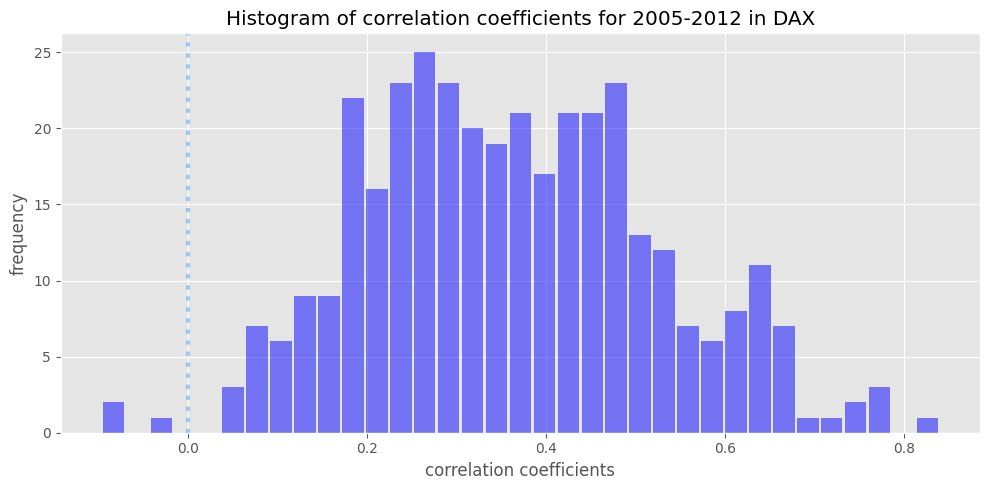

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), bins=35, color='#0000FF', rwidth=0.9, alpha=0.5)
ax.axvline(x=0, color='#1E90FF', linestyle=':', linewidth=3, alpha=0.4)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2005-2012 in DAX')
plt.tight_layout()
plt.show()

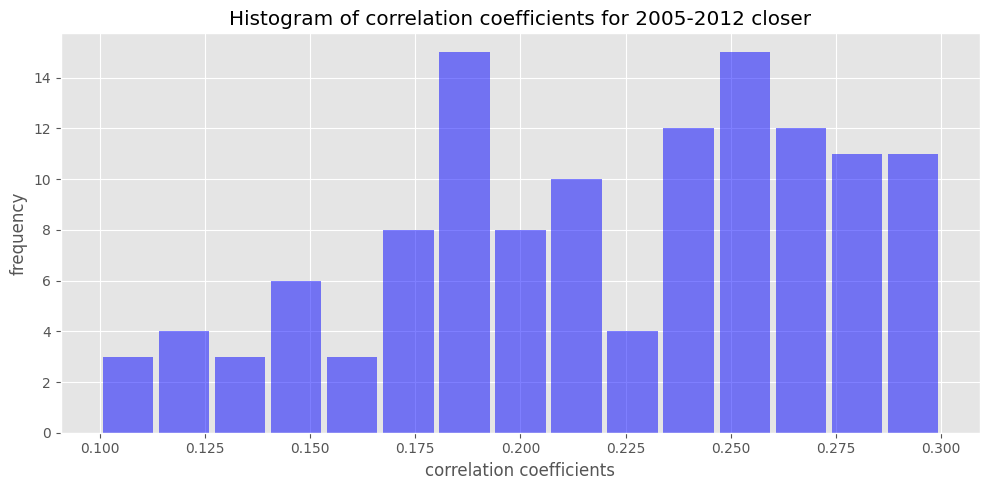

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), range=(0.10, 0.3), bins=15, color='#0000FF', rwidth=0.9, alpha=0.5)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2005-2012 closer')
plt.tight_layout()
plt.show()

In [ ]:
all_corrs = np.array(corr_list).flatten()
all_corrs_clean = all_corrs[~np.isnan(all_corrs)]

hist, bin_edges = np.histogram(all_corrs_clean, bins=75)
peak_bin = np.argmax(hist)
threshold = bin_edges[peak_bin]

print(f"Пик распределения: {threshold}")

Пик распределения: 0.1777920659428993


Выбор порогового значения коэффициента корреляции для проверки гипотезы осуществлялся на основе анализа эмпирического распределения. Пик распределения (мода) корреляционных коэффициентов за исследуемый период составил **0.18**.     
     
В качестве основного порога было выбрано значение **0.15**, что несколько ниже моды распределения. Данный выбор обусловлен следующими соображениями:   
*   Более низкий порог соответствует более строгому критерию "высокой корреляции";
*   Для инвестора значимым является превышение корреляций над уровнем, позволяющим строить диверсифицированный портфель;   
*   Робастность результатов: использование порога ниже моды позволяет проверить, сохраняется ли эффект при ужесточении критерия.   
